## Классические алгоритмы без ансамблирования
В этом ноутбуке вам нужно обучить модели на датасете классификации из предыдущего ноутбука и сравнить результаты. Вам будет предоставлен baseline, на основе которого вы будете доделывать предсказывающие модели. Оценка лабы будет зависеть от ROC-AUC на тестовых данных по следующим критериям:
\
AUC - на тестовых данных
- $AUC \leq 0.75$ - 0 баллов
- $0.75 < AUC \leq 0.76$ - 2 балла
- $0.76 < AUC \leq 0.77$ - 4 балла
- $0.77 < AUC \leq 0.78$ - 6 баллов
- $0.78 < AUC \leq 0.79$ - 8 баллов
- $AUC > 0.79$ - 10 баллов

\
В этой работе запрещено использовать ансамбли моделей (лес, бустинги и т.д.)!

In [661]:
from pygments.styles import default
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import roc_auc_score, precision_score, recall_score, roc_curve, accuracy_score

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [662]:
data = pd.read_csv('german.csv', sep=';')
print(data.head())

X = data.iloc[:, 1:].to_numpy()
y = data.iloc[:, 0].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

   Creditability  Account_Balance  Duration_of_Credit_monthly  \
0              1                1                          18   
1              1                1                           9   
2              1                2                          12   
3              1                1                          12   
4              1                1                          12   

   Payment_Status_of_Previous_Credit  Purpose  Credit_Amount  \
0                                  4        2           1049   
1                                  4        0           2799   
2                                  2        9            841   
3                                  4        0           2122   
4                                  4        0           2171   

   Value_Savings_Stocks  Length_of_current_employment  Instalment_per_cent  \
0                     1                             2                    4   
1                     1                             3               

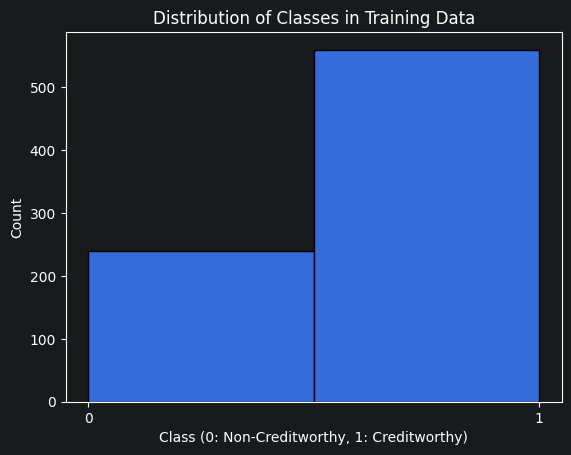

In [663]:
plt.hist(y_train, bins=2, edgecolor='k')
plt.xticks([0, 1])
plt.xlabel('Class (0: Non-Creditworthy, 1: Creditworthy)')
plt.ylabel('Count')
plt.title('Distribution of Classes in Training Data')
plt.show()

In [664]:
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

# Создание модели Logistic Regression
logistic_regression_model = LogisticRegression(C = 0.01)
logistic_regression_model.fit(X_train_sc, y_train)

# Создание модели Decision Tree
decision_tree_model = DecisionTreeClassifier(max_features=0.7, random_state=42, max_depth=6, min_samples_leaf=5)
decision_tree_model.fit(X_train, y_train)

# Создание модели K-Nearest Neighbors
knn_model = KNeighborsClassifier(weights='distance', n_neighbors=21, p=5)
knn_model.fit(X_train_sc, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",21
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",5
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [665]:
y_prob_logistic = logistic_regression_model.predict_proba(X_test_sc)[:, 1]
y_prob_decision_tree = decision_tree_model.predict_proba(X_test)[:, 1]
y_prob_knn = knn_model.predict_proba(X_test_sc)[:, 1]

y_pred_logistic = logistic_regression_model.predict(X_test_sc)
y_pred_decision_tree = decision_tree_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test_sc)

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
accuracy_decision_tree = accuracy_score(y_test, y_pred_decision_tree)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

roc_auc_logistic = roc_auc_score(y_test, y_prob_logistic)
roc_auc_decision_tree = roc_auc_score(y_test, y_prob_decision_tree)
roc_auc_knn = roc_auc_score(y_test, y_prob_knn)

precision_logistic = precision_score(y_test, y_pred_logistic)
precision_decision_tree = precision_score(y_test, y_pred_decision_tree)
precision_knn = precision_score(y_test, y_pred_knn)

recall_logistic = recall_score(y_test, y_pred_logistic)
recall_decision_tree = recall_score(y_test, y_pred_decision_tree)
recall_knn = recall_score(y_test, y_pred_knn)

print(f'Accuracy of Logistic Regression: {accuracy_logistic}')
print(f'Accuracy of Decision Tree: {accuracy_decision_tree}')
print(f'Accuracy of K-Nearest Neighbors: {accuracy_knn}')

print(f'ROC AUC of Logistic Regression: {roc_auc_logistic}')
print(f'ROC AUC of Decision Tree: {roc_auc_decision_tree}')
print(f'ROC AUC of K-Nearest Neighbors: {roc_auc_knn}')

print(f'Precision of Logistic Regression: {precision_logistic}')
print(f'Precision of Decision Tree: {precision_decision_tree}')
print(f'Precision of K-Nearest Neighbors: {precision_knn}')

print(f'Recall of Logistic Regression: {recall_logistic}')
print(f'Recall of Decision Tree: {recall_decision_tree}')
print(f'Recall of K-Nearest Neighbors: {recall_knn}')

Accuracy of Logistic Regression: 0.76
Accuracy of Decision Tree: 0.73
Accuracy of K-Nearest Neighbors: 0.765
ROC AUC of Logistic Regression: 0.8259523809523809
ROC AUC of Decision Tree: 0.7998809523809525
ROC AUC of K-Nearest Neighbors: 0.8051190476190476
Precision of Logistic Regression: 0.7738095238095238
Precision of Decision Tree: 0.864406779661017
Precision of K-Nearest Neighbors: 0.7569060773480663
Recall of Logistic Regression: 0.9285714285714286
Recall of Decision Tree: 0.7285714285714285
Recall of K-Nearest Neighbors: 0.9785714285714285


## Экспериментируйте
Для получения лучшего качества придется поэкспериментировать. Подсказка: попробуйте оптимизировать гиперпараметры модели

## Первый шаг
Сначала я использовала дефолтные значения у всех моделей

logistic_regression_model = LogisticRegression()\
logistic_regression_model.fit(X_train, y_train)\
decision_tree_model = DecisionTreeClassifier()\
decision_tree_model.fit(X_train, y_train)\
knn_model = KNeighborsClassifier()\
knn_model.fit(X_train, y_train)

получила такой ROC-AUC:

ROC AUC of Logistic Regression: 0.7793361383824216\
ROC AUC of Decision Tree: 0.7110799438990183\
ROC AUC of K-Nearest Neighbors: 0.5781907433380085

## Второй шаг
Добавила масштабирование к моделям LogisticRegression и KNeighboursClassifier

sc = StandardScaler()\
X_train_sc = sc.fit_transform(X_train)\
X_test_sc = sc.transform(X_test)\
logistic_regression_model = LogisticRegression()\
logistic_regression_model.fit(X_train_sc, y_train)\
decision_tree_model = DecisionTreeClassifier()\
decision_tree_model.fit(X_train, y_train)\
knn_model = KNeighborsClassifier()\
knn_model.fit(X_train_sc, y_train)

Получила прирост к обеим моделям (LR - с 0.78 до 0.79, KNN - с 0.58 до 0.75):

ROC AUC of Logistic Regression: 0.7919588592800374\
ROC AUC of Decision Tree: 0.706638616175783\
ROC AUC of K-Nearest Neighbors: 0.7483052828424497

## Третий шаг
Пробую подобрать параметр С для Logistic Regression:

при C = 0.001:\
ROC AUC of Logistic Regression: 0.7859981299672745\
при C = 0.01:\
ROC AUC of Logistic Regression: 0.792192613370734\
при C = 0.1:\
ROC AUC of Logistic Regression: ROC AUC of Logistic Regression: 0.7917251051893408\
при C = 1 (дефолтное значение) - было выше\
при C = 10:\
ROC AUC of Logistic Regression: 0.7918419822346892

Вывод: при C = 0.01 предположительно получаем самое большое значение ROC AUC, оставляем его

## Четвертый шаг
Подключаю взвешивание по расстоянию для KNN:

knn_model = KNeighborsClassifier(weights='distance')

Результат:\
ROC AUC of K-Nearest Neighbors: 0.7571294997662459

Подбор количества соседей:

Здесь я подключила stratify = y (обеспечивает сохранение пропорций классов в обучающей и тестовой выборках)\
Засчет этого ROC AUC выросло и у LR (0.8259523809523809)

при k = 3:\
ROC AUC of K-Nearest Neighbors: 0.7364285714285713\
при k = 5 (дефолтное значение) - было выше\
при k = 7:\
ROC AUC of K-Nearest Neighbors: 0.7820238095238096\
при k = 10:\
ROC AUC of K-Nearest Neighbors: 0.7855952380952381\
при k = 15:\
ROC AUC of K-Nearest Neighbors: 0.7822619047619047\
при k = 20:\
ROC AUC of K-Nearest Neighbors: 0.7845238095238095\
при k = 25:\
ROC AUC of K-Nearest Neighbors: 0.7836904761904763\
при k = 21:\
ROC AUC of K-Nearest Neighbors: 0.79\
при k = 22:\
ROC AUC of K-Nearest Neighbors: 0.7846428571428571

Вывод: при k = 21 предположительно получаем самое большое значение ROC AUC, оставляем его

## Пятый шаг
Подбираю параметр p (степень в формуле расстояния Минковского):

при p = 1:\
ROC AUC of K-Nearest Neighbors: 0.7821428571428571\
при p = 2 (дефолтное значение) - было выше\
при p = 3:\
ROC AUC of K-Nearest Neighbors: 0.7901190476190476\
при p = 5:\
ROC AUC of K-Nearest Neighbors: 0.8051190476190476

Вывод: при p = 5 уже получаем хороший результат

Итого:\
knn_model = KNeighborsClassifier(weights='distance', n_neighbors=21, p=5)\
knn_model.fit(X_train_sc, y_train)

## Шестой шаг
Подключаю random_state = 42, чтобы дерево строилось одинаково при каждом запуске

Подбираю количество признаков:

при max_features = 0.5:\
ROC AUC of Decision Tree: 0.6202380952380953\
при max_features = 0.7:\
ROC AUC of Decision Tree: 0.6583333333333333\
при max_features = 0.9:\
ROC AUC of Decision Tree: 0.6166666666666667\
при max_features = 0.8:\
ROC AUC of Decision Tree: 0.6285714285714286

Вывод: при max_features = 0.7 предположительно получаем самое большое значение ROC AUC, оставляем его

## Седьмой шаг
Подбираю максимальную глубину дерева:

при max_depth = 3:\
ROC AUC of Decision Tree: 0.725\
при max_depth = 5:\
ROC AUC of Decision Tree: 0.7576190476190476\
при max_depth = 7:\
ROC AUC of Decision Tree: 0.728452380952381\
при max_depth = 6:\
ROC AUC of Decision Tree: 0.760357142857143

Вывод: при max_depth = 6 предположительно получаем самое большое значение ROC AUC, оставляем его

## Восьмой шаг
Подбираю минимальное количество объектов, которое может оказаться в конечном узле дерева:

при min_samples_leaf = 5:\
ROC AUC of Decision Tree: 0.7998809523809525\
при min_samples_leaf = 4:\
ROC AUC of Decision Tree: 0.7750595238095238
при min_samples_leaf = 6:\
ROC AUC of Decision Tree: 0.7687500000000002

Вывод: при min_samples_leaf = 5 предположительно получаем самое большое значение ROC AUC, оставляем его

Итого:\
decision_tree_model = DecisionTreeClassifier(max_features=0.7, random_state=42, max_depth=6, min_samples_leaf=5)\
decision_tree_model.fit(X_train, y_train)

Теперь у всех трех моделей ROC AUC > 0.79